In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [10]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m")


ff_df.index = ff_df.index + pd.offsets.MonthEnd(0)
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100
ff_df = ff_df.loc[(ff_df.index >= '1964-01-01') & (ff_df.index < '2025-01-01')]
ff_df.rename(columns={"RF": "RiskFreeRate"}, inplace=True)
ff_df.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
2024-08-31,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040
2024-12-31,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037


In [11]:
constituent_data = pd.read_csv('sp500_returns_with_tickers.csv')

# Parse 'date' column to datetime
constituent_data["date"] = pd.to_datetime(constituent_data["date"])

# Filter by date
constituent_data = constituent_data.loc[
    (constituent_data["date"] > '1963-12-31') &
    (constituent_data["date"] <= '2024-12-31')
]

# Set datetime index
constituent_data.set_index("date", inplace=True)

# Convert index to calendar month-end (regardless of Feb 28/29 or 30/31 issues)
constituent_data.index = constituent_data.index.to_period('M').to_timestamp('M')
tickers = constituent_data.columns
constituent_data.tail()

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.101287,0.044149,NaN,NaN,0.127253,...,NaN,-0.045297,0.070945,-0.034608,0.208365,NaN,0.136817,NaN,0.013626,0.381469
2024-12-31,NaN,NaN,NaN,NaN,NaN,-0.098464,-0.004629,NaN,NaN,-0.076793,...,NaN,0.434045,-0.062506,-0.018765,-0.005997,NaN,-0.176142,NaN,-0.094742,0.170008


In [12]:
excess_returns = constituent_data.subtract(ff_df['RiskFreeRate'], axis=0)
factor_data = ff_df.drop(columns=["RiskFreeRate"])
factor_data["Mkt-RF"]

1964-01-31    0.0227
1964-02-29    0.0155
1964-03-31    0.0141
1964-04-30    0.0011
1964-05-31    0.0141
               ...  
2024-08-31    0.0161
2024-09-30    0.0173
2024-10-31   -0.0100
2024-11-30    0.0649
2024-12-31   -0.0315
Name: Mkt-RF, Length: 732, dtype: float64

In [13]:
merged_df = pd.concat([excess_returns, ff_df], axis=1)
merged_df

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,GNRC,QEP,CBOE,TSLA,Mkt-RF,SMB,HML,RMW,CMA,RiskFreeRate
1964-01-31,0.065548,-0.031846,0.066915,NaN,0.026083,NaN,NaN,NaN,-0.010371,NaN,...,NaN,NaN,NaN,NaN,0.0227,0.0010,0.0163,0.0021,0.0148,0.0030
1964-02-29,0.041174,0.032054,0.053400,NaN,-0.030861,NaN,NaN,NaN,0.037004,NaN,...,NaN,NaN,NaN,NaN,0.0155,0.0033,0.0281,0.0011,0.0081,0.0026
1964-03-31,-0.003100,0.044268,0.078339,NaN,0.067036,NaN,NaN,NaN,0.020710,NaN,...,NaN,NaN,NaN,NaN,0.0141,0.0141,0.0329,-0.0203,0.0298,0.0031
1964-04-30,0.000736,-0.032923,-0.016911,NaN,-0.049412,NaN,NaN,NaN,-0.038111,NaN,...,NaN,NaN,NaN,NaN,0.0011,-0.0148,-0.0054,-0.0132,-0.0113,0.0029
1964-05-31,-0.013470,0.025971,-0.020521,NaN,-0.040294,NaN,NaN,NaN,-0.019632,NaN,...,NaN,NaN,NaN,NaN,0.0141,-0.0062,0.0181,-0.0015,0.0013,0.0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,NaN,NaN,NaN,NaN,0.008395,-0.005900,NaN,NaN,-0.076335,...,0.000660,NaN,0.117918,-0.082191,0.0161,-0.0356,-0.0110,0.0073,0.0082,0.0048
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.202030,0.027548,NaN,NaN,0.034948,...,0.011013,NaN,-0.006580,0.217942,0.0173,-0.0091,-0.0277,0.0018,-0.0029,0.0040
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.016576,-0.059559,NaN,NaN,0.004638,...,0.038081,NaN,0.038566,-0.048925,-0.0100,-0.0088,0.0086,-0.0140,0.0098,0.0039
2024-11-30,NaN,NaN,NaN,NaN,NaN,0.097287,0.040149,NaN,NaN,0.123253,...,0.132817,NaN,0.009626,0.377469,0.0649,0.0462,0.0015,-0.0231,-0.0205,0.0040


In [14]:
def compute_rolling_betas_and_alpha(
    excess_returns_df,
    factor_df,
    portfolio_col,
    window=24,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False,
    beta_Momentum=False
):
    """computes rolling betas and alphas"""
    factor_flags = {
        "Mkt-RF": beta_MKT,
        "SMB": beta_SMB,
        "HML": beta_HML,
        "RMW": beta_RMW,
        "CMA": beta_CMA,
        "Mom": beta_Momentum
    }

    selected_factors = [factor for factor, include in factor_flags.items() if include]

    results = {"alpha": []}
    for factor in selected_factors:
        results[f"beta_{factor}"] = []

    index = []

    for i in range(window, len(excess_returns_df)):
        y = excess_returns_df[portfolio_col].iloc[i - window:i]
        X = factor_df[selected_factors].iloc[i - window:i]

        #drop rows with nans
        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < window:
            continue

        y = y[valid]
        X = X[valid]

        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()

        results["alpha"].append(model.params.get("const", float("nan")))
        for factor in selected_factors:
            results[f"beta_{factor}"].append(model.params.get(factor, float("nan")))

        index.append(excess_returns_df.index[i])

    return pd.DataFrame(results, index=index)

In [15]:
rolling_betas = []

for ticker in tickers:
    try:
        betas = compute_rolling_betas_and_alpha(
    excess_returns_df=excess_returns,
    factor_df=factor_data,
    portfolio_col=ticker,
    window=36,
    beta_MKT=True,
    beta_SMB=False,
    beta_HML=False,
    beta_RMW=False,
    beta_CMA=False
)
        betas["ticker"] = ticker
        rolling_betas.append(betas)
    except Exception as e:
        print(f"Error for {ticker}: {e}")

beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})

/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_78860/4012706941.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  beta_df = pd.concat(rolling_betas).reset_index().rename(columns={"index": "date"})


In [16]:
beta_df

,date,alpha,beta_Mkt-RF,ticker
0,1967-01-31,0.004128,1.368421,ACF
1,1967-02-28,0.003717,1.403478,ACF
2,1967-03-31,0.001825,1.389848,ACF
3,1967-04-30,0.004618,1.509165,ACF
4,1967-05-31,0.004460,1.493075,ACF
...,...,...,...,...
302538,2024-08-31,0.004466,1.880977,TSLA
302539,2024-09-30,0.001002,1.864024,TSLA
302540,2024-10-31,0.001759,1.960413,TSLA
302541,2024-11-30,-0.006656,1.750627,TSLA


In [17]:
beta_mkt_matrix = beta_df.pivot_table(
    index="date",
    columns="ticker",
    values="beta_Mkt-RF"
)

beta_mkt_matrix = beta_mkt_matrix.dropna(how='all')
beta_mkt_matrix

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,2.217403,NaN,NaN,2.013581,NaN,NaN,NaN,NaN,0.979182,NaN,...,NaN,NaN,1.279400,1.011713,NaN,NaN,1.076971,NaN,NaN,NaN
1967-02-28,2.165327,NaN,NaN,1.982664,NaN,NaN,NaN,NaN,1.160762,NaN,...,NaN,NaN,1.845629,0.914638,NaN,NaN,1.348319,NaN,NaN,NaN
1967-03-31,2.151039,NaN,NaN,1.922360,NaN,NaN,NaN,NaN,1.149658,NaN,...,NaN,NaN,1.820075,0.907140,NaN,NaN,1.344366,NaN,NaN,NaN
1967-04-30,1.999157,NaN,NaN,1.929657,NaN,NaN,NaN,NaN,1.303296,NaN,...,NaN,NaN,1.660824,0.961084,NaN,NaN,1.202130,NaN,NaN,NaN
1967-05-31,1.949958,NaN,NaN,1.882047,NaN,NaN,NaN,NaN,1.326681,NaN,...,NaN,NaN,1.562404,1.052422,NaN,NaN,1.329979,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,NaN,1.214030,NaN,1.305132,NaN,NaN,1.171161,NaN,NaN,0.440932,...,NaN,0.705485,NaN,NaN,0.703270,1.673707,NaN,NaN,NaN,1.001442
2024-09-30,NaN,1.182548,NaN,1.314620,NaN,NaN,1.171067,NaN,NaN,0.441901,...,NaN,0.710847,NaN,NaN,0.730322,1.661869,NaN,NaN,NaN,1.005565
2024-10-31,NaN,1.163425,NaN,NaN,NaN,NaN,1.156716,NaN,NaN,0.383366,...,NaN,0.695131,NaN,NaN,0.731116,1.652117,NaN,NaN,NaN,1.011549


In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def equal_abs_beta_contribution_weights(beta_row):
    #filter out nans and zero betas
    valid_betas = beta_row.dropna()
    valid_betas = valid_betas[valid_betas != 0]

    if valid_betas.empty:
        return pd.Series(dtype=float)

    betas = valid_betas.values
    n = len(betas)
    idx = valid_betas.index

    #objective function to minimize with target of 1/n
    def objective(w):
        contrib = w * betas
        return np.sum((contrib - 1/n)**2)

    #constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    ]

    #long only weights to mimic equal weight
    bounds = [(0, 1) for _ in range(n)]

    #start with inverted betas
    x0 = 1 / np.abs(betas)
    x0 = x0 / x0.sum()

    result = minimize(objective, x0, bounds=bounds, constraints=constraints)

    if not result.success:
        return pd.Series(dtype=float)

    weights = pd.Series(result.x, index=idx)

    full_weights = pd.Series(0.0, index=beta_row.index)
    full_weights.update(weights)

    return full_weights

In [19]:
from tqdm import tqdm
all_tickers = beta_mkt_matrix.columns
tqdm.pandas()

equal_abs_beta_weights = beta_mkt_matrix.progress_apply(
    lambda row: equal_abs_beta_contribution_weights(row).reindex(all_tickers, fill_value=0),
    axis=1
)

100%|██████████| 696/696 [13:20:13<00:00, 68.98s/it]    


In [20]:
equal_abs_beta_weights

ticker,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [21]:
returns_aligned = constituent_data.loc[equal_abs_beta_weights.index, equal_abs_beta_weights.columns]

assert equal_abs_beta_weights.shape == returns_aligned.shape
assert equal_abs_beta_weights.columns.equals(returns_aligned.columns)
assert equal_abs_beta_weights.index.equals(returns_aligned.index)


weighted_returns = equal_abs_beta_weights * returns_aligned

equal_beta_portfolio_return = weighted_returns.sum(axis=1)

In [22]:
equal_beta_portfolio_return

date
1967-01-31    0.105809
1967-02-28    0.007303
1967-03-31    0.043577
1967-04-30    0.032736
1967-05-31   -0.027935
                ...   
2024-08-31    0.030202
2024-09-30    0.016253
2024-10-31   -0.016896
2024-11-30    0.054184
2024-12-31   -0.063435
Length: 696, dtype: float64

In [23]:
equal_beta_portfolio_return.index = equal_beta_portfolio_return.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)

print(equal_beta_portfolio_return.head())

date
1967-01-01    0.105809
1967-02-01    0.007303
1967-03-01    0.043577
1967-04-01    0.032736
1967-05-01   -0.027935
dtype: float64


In [24]:
sp500_returns = pd.read_csv("sp500_capweighted_returns.csv")
sp500_returns['date'] = pd.to_datetime(sp500_returns['date'])
sp500_returns.set_index('date', inplace=True)
sp500_returns.index = sp500_returns.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)
sp500_returns

,0
date,
1960-01-01,-0.067093
1960-02-01,0.017111
1960-03-01,-0.010623
1960-04-01,-0.013724
1960-05-01,0.037913
...,...
2024-08-01,0.028116
2024-09-01,0.025856
2024-10-01,-0.004786


In [25]:
common_index = sp500_returns.index.intersection(equal_beta_portfolio_return.index)
sp500_returns = sp500_returns.loc[common_index]
equal_beta_portfolio_return = equal_beta_portfolio_return.loc[common_index]
sp500_returns.columns = ["S&P 500 Return"]
equal_beta_portfolio_return = equal_beta_portfolio_return.to_frame(name="EBC Return")
equal_beta_portfolio_return

,EBC Return
date,
1967-01-01,0.105809
1967-02-01,0.007303
1967-03-01,0.043577
1967-04-01,0.032736
1967-05-01,-0.027935
...,...
2024-08-01,0.030202
2024-09-01,0.016253
2024-10-01,-0.016896


In [46]:
spread = sp500_returns["S&P 500 Return"] - equal_beta_portfolio_return["EBC Return"]
spread = spread.to_frame(name="Spread Return")
spread
spread.to_csv("spread.csv")

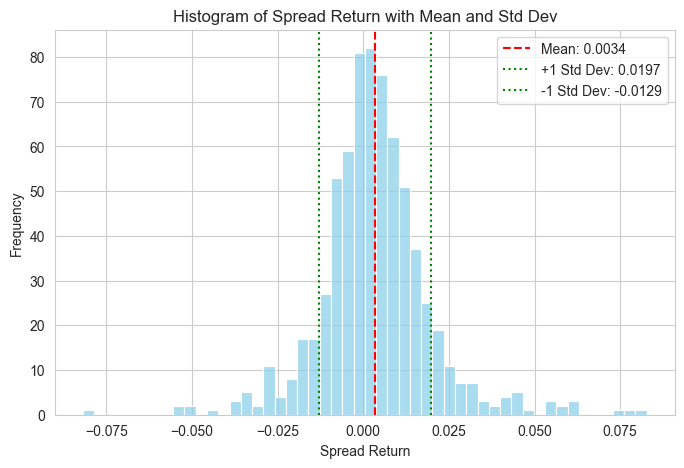

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

#mean and std
mean_val = spread['Spread Return'].mean()
std_val = spread['Spread Return'].std()

plt.figure(figsize=(8,5))
sns.histplot(spread['Spread Return'], bins=50, kde=False, color='skyblue', alpha=0.7)


plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')


plt.axvline(mean_val + std_val, color='green', linestyle=':', label=f'+1 Std Dev: {mean_val + std_val:.4f}')
plt.axvline(mean_val - std_val, color='green', linestyle=':', label=f'-1 Std Dev: {mean_val - std_val:.4f}')

plt.title("Histogram of Spread Return with Mean and Std Dev")
plt.xlabel("Spread Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



In [1]:
equal_abs_beta_weights
for ticker in equal_abs_beta_weights.columns:
    ticker.plot()

NameError: name 'equal_abs_beta_weights' is not defined

In [29]:
import numpy as np
import pandas as pd

def distance_from_equal_weights(row):
    #non nan and 0
    active = row[(row.notna()) & (row != 0)]

    if active.empty:
        return np.nan

    n_active = len(active)
    equal_w = 1 / n_active

    #equal weights
    equal_weights = pd.Series(equal_w, index=active.index)

    # euclidean distance
    dist = np.linalg.norm(active.values - equal_weights.values)
    return dist

#apply to each row
distance_series = equal_abs_beta_weights.apply(distance_from_equal_weights, axis=1)
distance_series.name = "Distance from Equal Weights (active stocks only)"


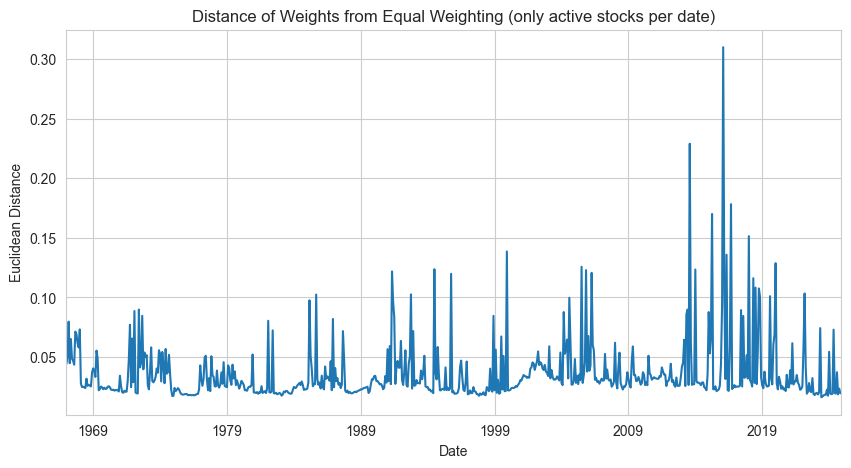

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
distance_series.plot()
plt.title("Distance of Weights from Equal Weighting (only active stocks per date)")
plt.ylabel("Euclidean Distance")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [31]:
max_dist_date = distance_series.idxmax()
weights_on_max_dist_date = equal_abs_beta_weights.loc[max_dist_date]
nonzero_weights = weights_on_max_dist_date[weights_on_max_dist_date != 0]
nonzero_weights

ticker
A.1      0.001388
AAPL     0.001434
ABBV     0.001194
ABT      0.001309
ACN.1    0.001874
           ...   
XYL      0.001412
YHOO     0.000907
YUM      0.001966
ZBH      0.001676
ZION     0.001464
Name: 2016-02-29 00:00:00, Length: 423, dtype: float64

In [32]:
max_weight = nonzero_weights.max()
max_weight = nonzero_weights.max()
max_weight_ticker = nonzero_weights.idxmax()
print(f"Max weight: {max_weight:.4f} (Ticker: {max_weight_ticker})")

Max weight: 0.3117 (Ticker: EXC)


In [33]:
beta_value = beta_mkt_matrix.loc[max_dist_date, max_weight_ticker]
print(f"Beta of {max_weight_ticker} on {max_dist_date}: {beta_value}")

Beta of EXC on 2016-02-29 00:00:00: 0.002301364284780859


In [34]:
weighted_betas = equal_abs_beta_weights * beta_mkt_matrix

#contribtion data frame
print(f"Weighted betas: {weighted_betas}")

#weighted sum to see ecb beta
portfolio_beta = weighted_betas.sum(axis=1)
print(portfolio_beta.tail())


Weighted betas: ticker             A       A.1  AAF       AAL  AAL.1  AAP      AAPL  AAV  \
date                                                                       
1967-01-31  0.002222       NaN  NaN  0.002097    NaN  NaN       NaN  NaN   
1967-02-28  0.002187       NaN  NaN  0.002194    NaN  NaN       NaN  NaN   
1967-03-31  0.002101       NaN  NaN  0.002102    NaN  NaN       NaN  NaN   
1967-04-30  0.002145       NaN  NaN  0.002105    NaN  NaN       NaN  NaN   
1967-05-31  0.002078       NaN  NaN  0.002115    NaN  NaN       NaN  NaN   
...              ...       ...  ...       ...    ...  ...       ...  ...   
2024-08-31       NaN  0.001957  NaN  0.001913    NaN  NaN  0.002015  NaN   
2024-09-30       NaN  0.001980  NaN  0.001950    NaN  NaN  0.001968  NaN   
2024-10-31       NaN  0.001979  NaN       NaN    NaN  NaN  0.001984  NaN   
2024-11-30       NaN  0.001956  NaN       NaN    NaN  NaN  0.001993  NaN   
2024-12-31       NaN  0.001975  NaN       NaN    NaN  NaN  0.002024  NaN

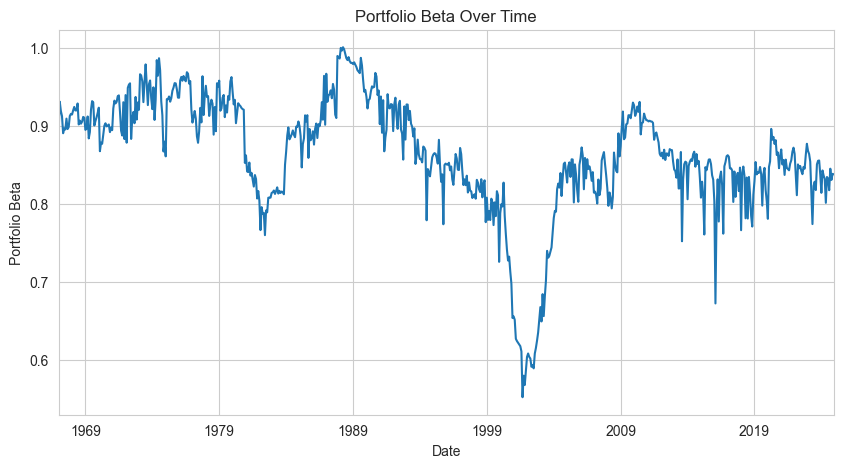

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
portfolio_beta.plot()
plt.title("Portfolio Beta Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Beta")
plt.grid(True)
plt.show()


In [36]:
cum_spread_return = np.log1p(spread["Spread Return"]).cumsum()
sp_cum_return = np.log1p(sp500_returns["S&P 500 Return"]).cumsum()
EBC_cum_return = np.log1p(equal_beta_portfolio_return["EBC Return"]).cumsum()
target_index = EBC_cum_return.index
target_index

DatetimeIndex(['1967-01-01', '1967-02-01', '1967-03-01', '1967-04-01',
               '1967-05-01', '1967-06-01', '1967-07-01', '1967-08-01',
               '1967-09-01', '1967-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=696, freq=None)

In [37]:

preference = pd.read_csv("Preference Returns.csv", index_col=0, parse_dates=True)
preference.index = pd.to_datetime(preference.index).to_period("M").to_timestamp()
preference_cum_return = np.log1p(preference["Preference Return"]).cumsum()
preference_cum_return = preference_cum_return.loc[target_index]

In [38]:
combined_returns = pd.DataFrame({
    "Spread Return": cum_spread_return,
    # "S&P Return": sp_cum_return,
    # "EBC Return": EBC_cum_return,
    "Preference": preference_cum_return
}, index=target_index)

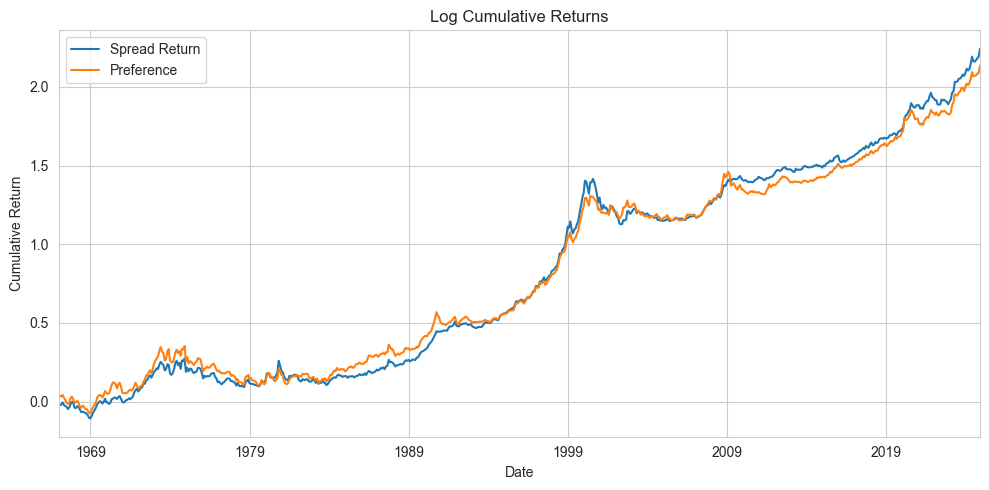

In [39]:
plt.figure(figsize=(10, 5))
combined_returns.plot(ax=plt.gca())
plt.title("Log Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
combined_returns = pd.DataFrame({
    "Spread Return": cum_spread_return,
    "S&P Return": sp_cum_return,
    "EBC Return": EBC_cum_return,
    "Preference": preference_cum_return
}, index=target_index)

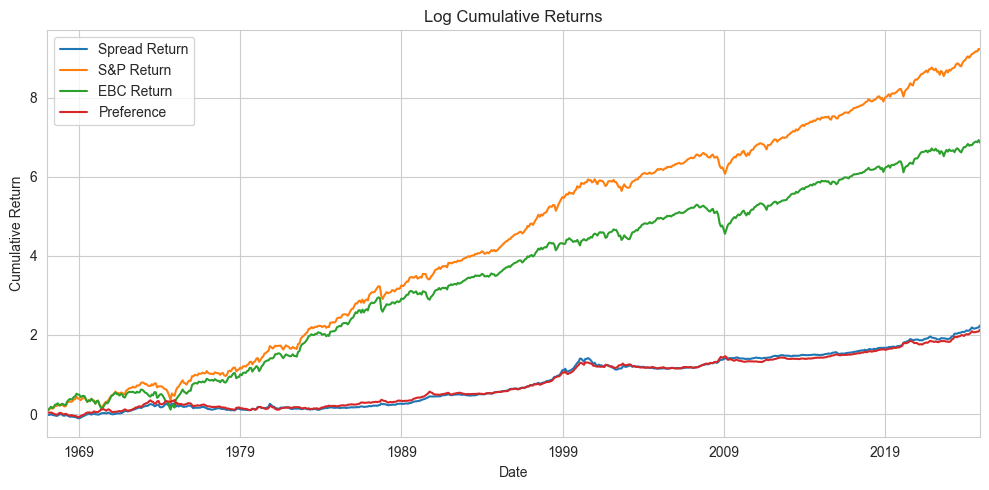

In [41]:
plt.figure(figsize=(10, 5))
combined_returns.plot(ax=plt.gca())
plt.title("Log Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
mag7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']  # adjust if using tickers like 'GOOG' or 'FB'
mag7_returns = excess_returns[mag7].copy()

In [43]:
betas_pref = {}
betas_spread = {}

for ticker in mag7:
    returns_ticker = excess_returns[ticker].dropna()

    # intersect with factor dates
    valid_index = returns_ticker.index.intersection(preference.index).intersection(spread.index)
    if len(valid_index) < 36:  # need enough data
        continue

    df = pd.DataFrame({
        "y": returns_ticker.loc[valid_index],
        "Preference": preference.loc[valid_index]["Preference Return"],
        "Spread": spread.loc[valid_index]["Spread Return"]
    }).dropna()

    if len(df) < 24:
        continue  # not enough data to estimate beta reliably

    X = sm.add_constant(df[["Preference", "Spread"]])
    y = df["y"]
    model = sm.OLS(y, X).fit()

    betas_pref[ticker] = model.params["Preference"]
    betas_spread[ticker] = model.params["Spread"]

# Beta matrix
beta_df_fm = pd.DataFrame({
    "beta_pref": betas_pref,
    "beta_spread": betas_spread
}).dropna()


## Positive Negative Breakdown

Positive return months: 696
Avg positive return: Spread Return    0.012266
dtype: float64
Negative return months: 696
Avg negative return: Spread Return   -0.010199
dtype: float64


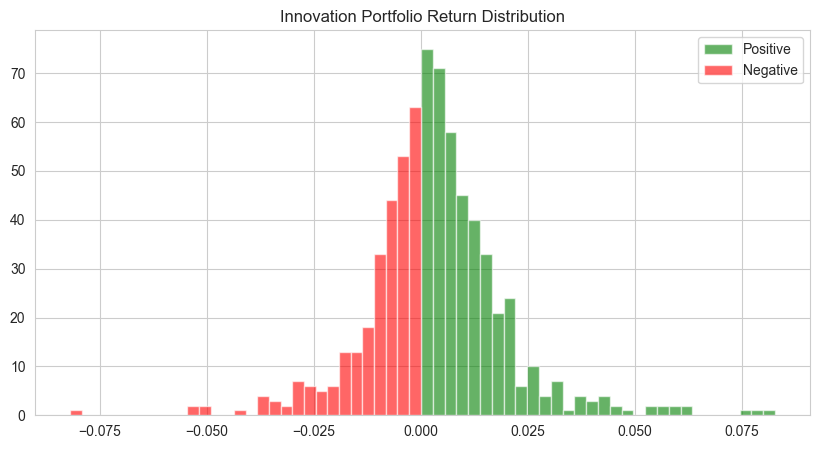

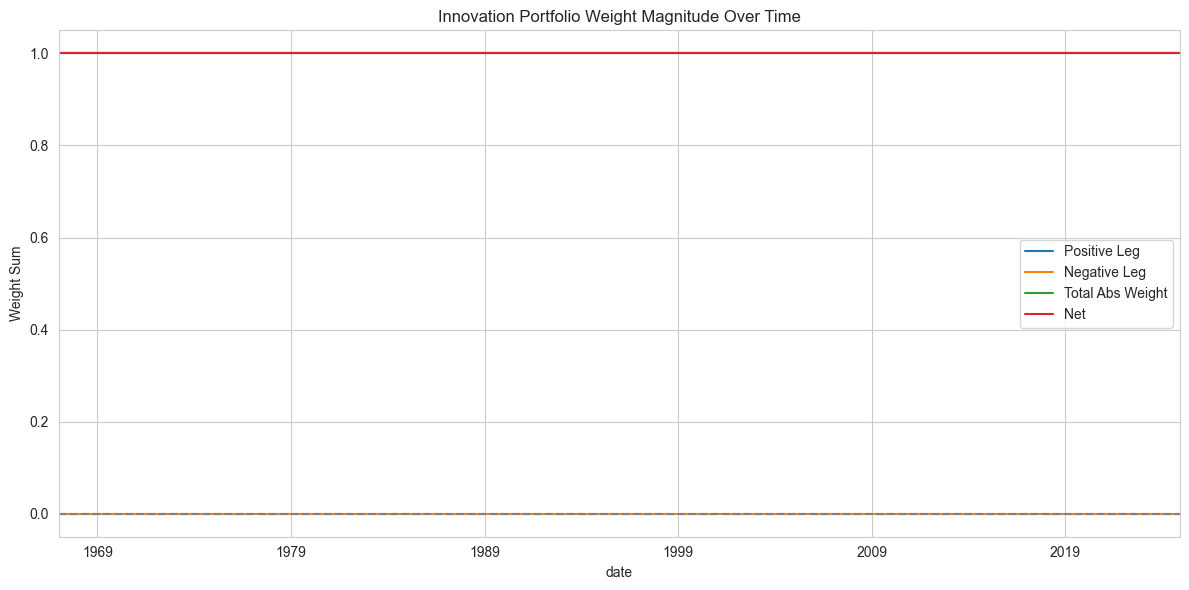

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

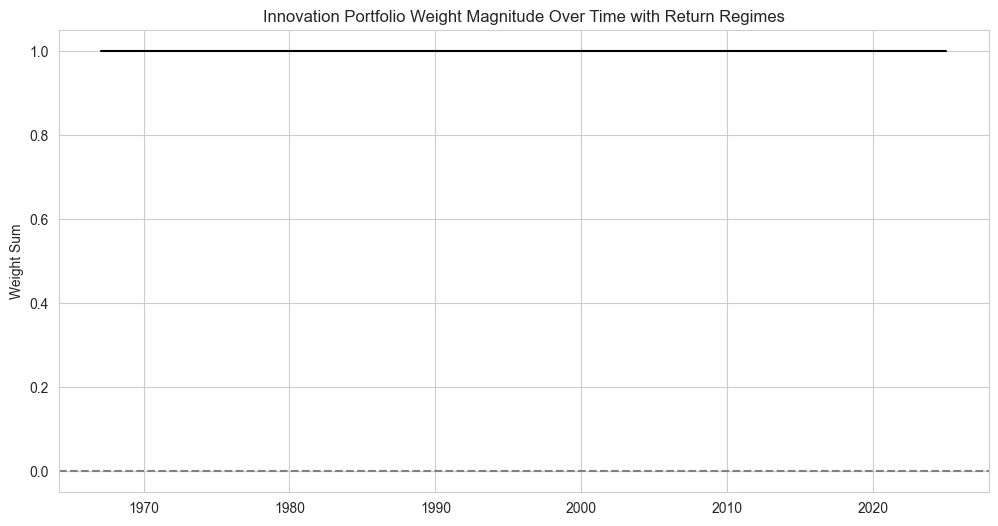

In [45]:
positive_returns = spread[spread > 0]
negative_returns = spread[spread < 0]

# Count and average magnitude
print("Positive return months:", len(positive_returns))
print("Avg positive return:", positive_returns.mean())
print("Negative return months:", len(negative_returns))
print("Avg negative return:", negative_returns.mean())

# Optional: histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(positive_returns, bins=30, alpha=0.6, label="Positive", color='green')
plt.hist(negative_returns, bins=30, alpha=0.6, label="Negative", color='red')
plt.title("Innovation Portfolio Return Distribution")
plt.legend()
plt.grid(True)
plt.show()
# Compute long/short legs of innovation weights
positive_leg = equal_abs_beta_weights.clip(lower=0).sum(axis=1)
negative_leg = equal_abs_beta_weights.clip(upper=0).sum(axis=1)

# Combine into a DataFrame
innovation_weight_magnitude = pd.DataFrame({
    "Positive Leg": positive_leg,
    "Negative Leg": negative_leg,
    "Total Abs Weight": positive_leg - negative_leg  # should always be positive
})

# Optional: net exposure (should be near 0 by construction)
innovation_weight_magnitude["Net"] = positive_leg + negative_leg
innovation_weight_magnitude.plot(figsize=(12, 6), title="Innovation Portfolio Weight Magnitude Over Time")
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Weight Sum")
plt.grid(True)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the innovation weight magnitude
ax.plot(innovation_weight_magnitude.index, innovation_weight_magnitude["Total Abs Weight"], label="Total Abs Weight",
        color='black')
ax.axhline(0, color='gray', linestyle='--')
ax.set_title("Innovation Portfolio Weight Magnitude Over Time with Return Regimes")
ax.set_ylabel("Weight Sum")
ax.grid(True)

# Add more visible background shading
for date, value in spread.items():
    color = 'lightgreen' if value > 0 else 'lightcoral'
    ax.axvspan(date, date, color=color, alpha=0.35)

plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(12, 6))

# Extract the series
abs_weight = innovation_weight_magnitude["Total Abs Weight"]
rolling_avg = abs_weight.rolling(window=36).mean()

# Plot both lines
ax.plot(abs_weight.index, abs_weight, label="Total Abs Weight", color='black', linewidth=1)
ax.plot(rolling_avg.index, rolling_avg, label="24-Month Rolling Avg", color='blue', linewidth=2)

# Add horizontal line at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add background shading for Innovation return sign
for date, value in spread.items():
    color = 'lightgreen' if value > 0 else 'lightcoral'
    ax.axvspan(date, date, color=color, alpha=0.35)

# Labels and legend
ax.set_title("Innovation Portfolio Weight Magnitude with Return Regime Shading")
ax.set_ylabel("Weight Sum")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

# Use raw Total Abs Weight
abs_weight = innovation_weight_magnitude["Total Abs Weight"]
dates = abs_weight.index

# Number of months per chunk
chunk_size = 120
n_chunks = len(abs_weight) // chunk_size

# Make individual 24-month plots
for i in range(n_chunks):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size
    if end_idx > len(abs_weight):
        break

    # Slice for this chunk
    chunk_weights = abs_weight.iloc[start_idx:end_idx]
    chunk_dates = chunk_weights.index
    chunk_returns = spread.loc[chunk_dates]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(chunk_dates, chunk_weights, color='black', label='Total Abs Weight')

    # Background shading based on return sign
    for date, value in chunk_returns.items():
        color = 'lightgreen' if value > 0 else 'lightcoral'
        ax.axvspan(date, date, color=color, alpha=0.35)

    ax.set_title(f"Total Abs Weight — {chunk_dates[0]} to {chunk_dates[-1]}")
    ax.set_ylabel("Weight Sum")
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
